* XGBoost 버전 확인

In [3]:
import xgboost

print(xgboost.__version__)

2.1.4


1. 위스콘신 유방암 데이터셋 컬럼 설명

이 데이터는 종양의 세포 핵(nucleus) 모양을 여러 지표로 표현한 것입니다.
각 feature는 다음 10개의 기본 값에 대해,

mean : 평균값

error : 표준오차(측정값의 변동성)

worst : 가장 안 좋은(최대) 값 근처의 평균

을 저장해놨다고 보면 됩니다.

| 컬럼명                        | 의미                           | 쉽게 설명                               |
| -------------------------- | ---------------------------- | ----------------------------------- |
| **mean radius**            | 세포 핵 반지름의 평균                 | 종양 이미지를 봤을 때 **세포 핵 크기의 평균 반경**     |
| **mean texture**           | 그레이스케일 값의 표준편차(질감) 평균        | 밝기 다양성 → **표면 질감의 거칠기/불균일성의 평균**    |
| **mean perimeter**         | 둘레 길이 평균                     | 세포 핵의 **경계 선 길이 평균**                |
| **mean area**              | 면적 평균                        | 세포 핵이 차지하는 **면적의 평균 크기**            |
| **mean smoothness**        | 반지름 길이 변화 정도 평균              | 경계가 **얼마나 매끈한지(=거칠지 않은지)** 평균       |
| **mean compactness**       | (perimeter² / area - 1.0) 평균 | **얼마나 조밀한지/둥근지**를 나타내는 값            |
| **mean concavity**         | 오목한 부분의 심각도 평균               | 경계가 **안쪽으로 파인 정도의 평균**              |
| **mean concave points**    | 오목한 부분의 개수 평균                | 경계가 **안쪽으로 꺾인 지점의 개수 평균**           |
| **mean symmetry**          | 대칭성 평균                       | 세포 모양이 **얼마나 좌우로 대칭적인지** 평균         |
| **mean fractal dimension** | 프랙탈 차원 평균                    | 경계의 복잡도, **“해안선 길이”처럼 복잡할수록 커지는 값** |


| 컬럼명                         | 의미              |
| --------------------------- | --------------- |
| **radius error**            | 반지름 값의 표준오차     |
| **texture error**           | 질감 값의 표준오차      |
| **perimeter error**         | 둘레 값의 표준오차      |
| **area error**              | 면적 값의 표준오차      |
| **smoothness error**        | 매끄러움 값의 표준오차    |
| **compactness error**       | 조밀도 값의 표준오차     |
| **concavity error**         | 오목함 심각도 값의 표준오차 |
| **concave points error**    | 오목 지점 개수의 표준오차  |
| **symmetry error**          | 대칭성 값의 표준오차     |
| **fractal dimension error** | 프랙탈 차원 값의 표준오차  |

| 컬럼명                         | 의미                                |
| --------------------------- | --------------------------------- |
| **worst radius**            | 가장 큰 반지름 값들에서 뽑은 평균 (최악에 가까운 반지름) |
| **worst texture**           | 가장 심한 질감(표준편차) 값들의 평균             |
| **worst perimeter**         | 가장 큰 둘레 값들의 평균                    |
| **worst area**              | 가장 큰 면적 값들의 평균                    |
| **worst smoothness**        | 가장 덜 매끄러운 상태의 평균                  |
| **worst compactness**       | 가장 조밀한(또는 비정상적인) 상태의 평균           |
| **worst concavity**         | 가장 심하게 오목한 상태의 평균                 |
| **worst concave points**    | 가장 오목한 지점이 많은 상태의 평균              |
| **worst symmetry**          | 가장 비대칭적인 상태의 평균                   |
| **worst fractal dimension** | 가장 복잡한 경계 상태의 평균                  |


➡ 요약하면:

mean 계열: 종양 전체의 전반적인 특징

error 계열: 값의 변동성 (안정적인지, 들쭉날쭉한지)

worst 계열: 가장 안 좋은 쪽 특성 (악성 판별에 특히 중요)

## 1. XGBoost 개념 및 동작 원리

🔷 **XGBoost(Xtreme Gradient Boosting)**란?

Gradient Boosting 알고리즘을 더 빠르고, 더 강력하고, 과적합에 강하게 만든 알고리즘.

데이터 분석 및 캐글 대회에서 가장 많이 사용되는 기법 중 하나.

결정트리(Decision Tree)를 **Weak Learner(약한 학습기)**로 사용하여 여러 개의 트리를 순차적으로 학습시켜 성능을 높임.

🔷 XGBoost 핵심 특징
1) Boosting 방식

하나의 트리를 학습한 후 다음 트리는 이전 트리의 오차를 보완하는 방향으로 학습

즉, "틀린 부분을 계속 보완하며 강한 모델" 생성

2) Gradient Boosting 기반

각 반복(iteration)에서 Loss Function(오차)을 줄이도록 Gradient 값을 사용해 트리가 생성됨.

3) 규제(Regularization) 포함

기존 GradientBoosting과 달리 L1, L2 규제를 포함

→ 과적합(Overfitting)을 방지하는 효과

4) 분산 처리 + 빠른 연산

자체적인 최적화(병렬 처리, sparsity 대응 등)로 학습 속도가 매우 빠름

5) Early Stopping 지원

검증셋의 성능이 일정 rounds 동안 좋아지지 않으면 학습 자동 종료
→ 시간 절약 + 과적합 방지

🔷 XGBoost의 동작 과정 요약

첫 번째 트리가 데이터 패턴을 학습

예측 오류(residual error = 실제 - 예측)를 계산

두 번째 트리는 이 오류를 줄이도록 학습

계속 반복하며 트리가 추가됨

모든 트리의 예측값을 합쳐 최종 예측
→ 약한 트리들이 모여 강한 예측기가 됨

### 파이썬 래퍼 XGBoost 적용 – 위스콘신 유방암 예측

In [1]:
import xgboost
# XGBoost 패키지가 정상적으로 설치되었는지 확인하기 위해 라이브러리를 불러온다.

print(xgboost.__version__)
# 현재 설치된 XGBoost의 버전을 출력하여 코드 실행 환경을 점검한다.


## 파이썬 래퍼 XGBoost 적용 – 위스콘신 유방암 예측

import xgboost as xgb
# XGBoost 알고리즘을 파이썬 환경에서 사용하기 위해 xgboost 모듈을 xgb라는 이름으로 가져온다.

from xgboost import plot_importance
# 학습된 모델에서 어떤 특징이 중요한지 시각적으로 확인할 수 있는 plot_importance 함수를 불러온다.

import pandas as pd
# 데이터 전처리, 테이블 형태의 데이터 처리 등을 위해 pandas를 사용한다.

import numpy as np
# 수학적 계산이나 배열 형태의 자료 처리를 위해 numpy를 사용한다.

from sklearn.datasets import load_breast_cancer
# 위스콘신 유방암 데이터셋을 불러오기 위한 함수를 import 한다.

from sklearn.model_selection import train_test_split
# 전체 데이터를 학습용과 테스트용으로 나누기 위해 train_test_split 함수를 사용한다.

import warnings
warnings.filterwarnings('ignore')
# 경고 메시지가 출력되면 보기 불편하므로 모든 경고를 무시하도록 설정한다.


# 유방암 데이터셋을 메모리로 불러온다.
dataset = load_breast_cancer()

# 불러온 데이터셋에서 입력 변수(features)만 분리한다.
X_features = dataset.data

# 정답 라벨(target: 악성/양성)을 y_label 변수에 저장한다.
y_label = dataset.target


# 입력 변수들을 pandas DataFrame 구조로 변환하여 컬럼명을 부여한다.
cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)

# DataFrame의 마지막 열에 target 값을 추가하여 전체 정보가 한 테이블에 있도록 구성한다.
cancer_df['target'] = y_label

# 상위 3개의 데이터만 확인하여 형태가 잘 생성되었는지 확인한다.
cancer_df.head(3)


2.1.4


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [2]:
# 데이터셋이 어떤 레이블을 사용하는지 출력하여 클래스명을 확인한다.
print(dataset.target_names)
# 출력: ['malignant' 'benign'] → 0은 악성, 1은 양성을 의미한다.

# target 컬럼의 값이 0과 1이 각각 몇 개 있는지 출력하여 데이터 분포를 확인한다.
print(cancer_df['target'].value_counts())

['malignant' 'benign']
1    357
0    212
Name: target, dtype: int64


In [3]:
# feature 컬럼만 선택하기 위해 마지막 target 열을 제외한 모든 열을 입력 데이터로 사용한다.
X_features = cancer_df.iloc[:, :-1]

# 마지막 열(target)만 선택하여 label 데이터로 사용한다.
y_label = cancer_df.iloc[:, -1]


# 전체 데이터를 학습용 80%, 테스트용 20% 비율로 분리한다.
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156
)


# 학습 데이터를 다시 학습(90%)과 검증(10%) 데이터로 나누어 모델 튜닝에 활용한다.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156
)

# 학습/테스트 데이터의 크기를 출력하여 분리된 비율이 예상대로인지 확인한다.
print(X_train.shape, X_test.shape)

# 학습 데이터가 다시 학습/검증으로 잘 분리되었는지 크기를 출력한다.
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [4]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안될 경우 X_train.values로 넘파이 변환.
# 학습, 검증, 테스트용 DMatrix를 생성.

# XGBoost가 계산을 최적화하기 위해 사용하는 DMatrix 구조로 학습 데이터를 변환한다.
dtr = xgb.DMatrix(data=X_tr, label=y_tr)

# 검증 데이터도 동일하게 DMatrix 형태로 변환한다.
dval = xgb.DMatrix(data=X_val, label=y_val)

# 테스트 데이터 역시 예측을 위해 DMatrix 형태로 준비한다.
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [5]:
# 모델 학습에 필요한 하이퍼파라미터를 설정한다.
params = {
    'max_depth': 3,               # 트리의 깊이를 제한하여 과적합을 방지한다.
    'eta': 0.05,                  # learning rate를 설정하여 한 번의 학습 단계에서 조정되는 크기를 줄인다.
    'objective': 'binary:logistic',  # 이진 분류 문제이므로 로지스틱 함수를 사용하여 확률로 예측한다.
    'eval_metric': 'logloss'      # 평가 지표로서 로그손실(logloss)을 사용하도록 지정한다.
}

# 최대 boosting 반복 횟수를 정의한다.
num_rounds = 400

In [6]:
# 학습 과정에서 평가할 데이터셋을 지정하여 early stopping에 활용한다.
eval_list = [(dtr, 'train'), (dval, 'eval')]
# 'eval' 데이터셋의 성능이 개선되지 않으면 학습을 조기 종료하기 위해 validation set이 필요하다.


# XGBoost 모델을 실제로 학습하는 부분이며 early stopping을 적용한다.
xgb_model = xgb.train(
    params=params,               # 설정한 하이퍼파라미터를 전달한다.
    dtrain=dtr,                  # 학습용 데이터를 전달한다.
    num_boost_round=num_rounds,  # 최대 boosting 반복 횟수를 지정한다.
    early_stopping_rounds=50,    # 50번 동안 성능이 좋아지지 않으면 학습을 자동으로 종료한다.
    evals=eval_list              # 학습 과정 중 성능 평가에 사용할 데이터셋 목록을 전달한다.
)

[0]	train-logloss:0.62480	eval-logloss:0.63104
[1]	train-logloss:0.58674	eval-logloss:0.60478
[2]	train-logloss:0.55226	eval-logloss:0.58223
[3]	train-logloss:0.52086	eval-logloss:0.56184
[4]	train-logloss:0.49192	eval-logloss:0.54118
[5]	train-logloss:0.46537	eval-logloss:0.52223
[6]	train-logloss:0.44029	eval-logloss:0.50287
[7]	train-logloss:0.41666	eval-logloss:0.48620
[8]	train-logloss:0.39525	eval-logloss:0.46974
[9]	train-logloss:0.37542	eval-logloss:0.45497
[10]	train-logloss:0.35701	eval-logloss:0.44131
[11]	train-logloss:0.33982	eval-logloss:0.43134
[12]	train-logloss:0.32297	eval-logloss:0.41972
[13]	train-logloss:0.30725	eval-logloss:0.40902
[14]	train-logloss:0.29327	eval-logloss:0.39883
[15]	train-logloss:0.27946	eval-logloss:0.38968
[16]	train-logloss:0.26691	eval-logloss:0.38150
[17]	train-logloss:0.25473	eval-logloss:0.37368
[18]	train-logloss:0.24385	eval-logloss:0.36666
[19]	train-logloss:0.23338	eval-logloss:0.35994
[20]	train-logloss:0.22320	eval-logloss:0.35374
[2

[170]	train-logloss:0.01317	eval-logloss:0.24117
[171]	train-logloss:0.01308	eval-logloss:0.24126
[172]	train-logloss:0.01299	eval-logloss:0.24046
[173]	train-logloss:0.01292	eval-logloss:0.23993
[174]	train-logloss:0.01284	eval-logloss:0.23985
[175]	train-logloss:0.01275	eval-logloss:0.23994
[176]	train-logloss:0.01268	eval-logloss:0.23986
[177]	train-logloss:0.01260	eval-logloss:0.23996
[178]	train-logloss:0.01253	eval-logloss:0.23943
[179]	train-logloss:0.01243	eval-logloss:0.23847
[180]	train-logloss:0.01236	eval-logloss:0.23842
[181]	train-logloss:0.01226	eval-logloss:0.23885
[182]	train-logloss:0.01220	eval-logloss:0.23828
[183]	train-logloss:0.01214	eval-logloss:0.23892
[184]	train-logloss:0.01205	eval-logloss:0.23804
[185]	train-logloss:0.01198	eval-logloss:0.23799
[186]	train-logloss:0.01191	eval-logloss:0.23809
[187]	train-logloss:0.01185	eval-logloss:0.23752
[188]	train-logloss:0.01176	eval-logloss:0.23662
[189]	train-logloss:0.01170	eval-logloss:0.23659
[190]	train-logloss:

In [7]:
# 테스트 데이터셋에 대해 모델이 예측한 확률값을 얻는다.
pred_probs = xgb_model.predict(dtest)

# 예측한 확률값 중 처음 10개만 출력하여 예측 결과의 형태를 확인한다.
print('predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10], 3))


# 예측된 확률값이 0.5보다 크면 양성(1), 그렇지 않으면 악성(0)으로 판단한다.
preds = [1 if x > 0.5 else 0 for x in pred_probs]

# 변환된 이진 예측값을 처음 10개 출력하여 실제 분류 형태를 확인한다.
print('예측값 10개만 표시:', preds[:10])



'''
출력결과해석

각 숫자는 “해당 샘플이 양성(benign, 1)일 확률”

예: 첫 번째 값 0.938 → 양성일 확률 93.8%, 즉 예측 값 = 1

네 번째 값 0.049 → 양성일 확률 4.9%, 즉 예측 값 = 0

0.5 기준으로 분류 --> 0.5 보다 크면 1(양성), 아니면 0(악성)
'''

predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.938 0.004 0.75  0.049 0.98  1.    0.999 0.999 0.998 0.001]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score
# 혼동행렬과 정확도 계산을 위한 지표를 불러온다.

from sklearn.metrics import precision_score, recall_score
# 정밀도와 재현율 계산을 위한 함수를 불러온다.

from sklearn.metrics import f1_score, roc_auc_score
# F1 score와 ROC-AUC 점수 계산에 필요한 함수들을 불러온다.


# 모델 성능을 종합적으로 출력하는 사용자 정의 함수이다.
def get_clf_eval(y_test, pred=None, pred_proba=None):

    confusion = confusion_matrix(y_test, pred)
    # 모델의 예측 결과가 실제 정답과 얼마나 일치하는지 혼동행렬로 계산한다.

    accuracy = accuracy_score(y_test, pred)
    # 전체 예측 중 얼마나 맞췄는지를 나타내는 정확도를 계산한다.

    precision = precision_score(y_test, pred)
    # 양성이라고 예측한 것 중 실제로 양성이 얼마나 되는지 정밀도를 계산한다.

    recall = recall_score(y_test, pred)
    # 실제 양성 중에서 얼마나 올바르게 맞추었는지 나타내는 재현율을 계산한다.

    f1 = f1_score(y_test, pred)
    # 정밀도와 재현율의 조화평균으로 F1 score를 계산한다.

    roc_auc = roc_auc_score(y_test, pred_proba)
    # ROC 곡선 아래 면적을 의미하는 AUC 값을 계산하여 예측의 신뢰성을 평가한다.

    print('오차 행렬')
    print(confusion)

    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(
        accuracy, precision, recall, f1, roc_auc
    ))
    # 앞에서 계산한 모든 성능 지표를 보기 좋게 출력한다.

In [9]:
get_clf_eval(y_test , preds, pred_probs)  # 성능 평가 함수를 호출하여 모델의 전체 성능을 확인한다.

'''
출력결과 해석
구분	의미
35	실제 0(악성)을 정확히 0으로 예측한 수
2	실제 0을 1로 잘못 예측한 수
2	실제 1을 0으로 잘못 예측한 수
75	실제 1을 정확히 1로 예측한 수

📌 정확도: 0.9649

전체의 약 **96.5%**를 맞춤

📌 정밀도: 0.9740

양성이라고 예측한 것 중 **97.4%**가 실제 양성

📌 재현율: 0.9740

실제 양성 중 **97.4%**를 맞춤
→ 암 탐지에서는 재현율이 매우 중요 (암을 놓치면 안 되므로)

📌 F1 Score: 0.9740

정밀도와 재현율의 균형도 매우 높음

📌 AUC: 0.9965

ROC Curve 아래 면적이 1에 매우 가까움
'''

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740,    F1: 0.9740, AUC:0.9965


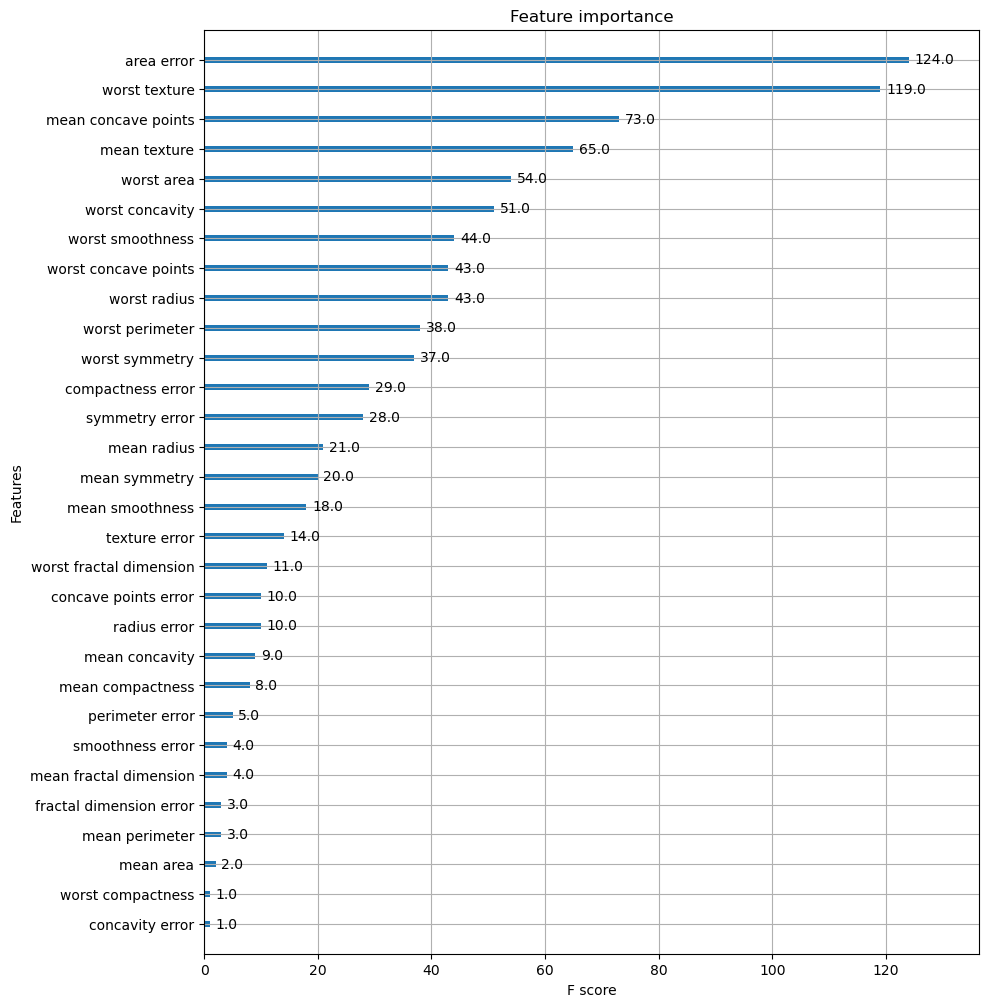

In [10]:
import matplotlib.pyplot as plt
# 특징 중요도 시각화를 위해 matplotlib을 불러온다.

%matplotlib inline
# 그래프를 노트북 환경에서 바로 보이도록 inline 설정을 해준다.

# 그래프 크기를 설정하여 넓은 공간에 시각화가 되도록 한다.
fig, ax = plt.subplots(figsize=(10, 12))

# XGBoost 모델이 학습 중 어떤 feature를 많이 사용했는지를 시각적으로 표현한다.
plot_importance(xgb_model, ax=ax)

# 그래프를 고화질 TIFF 파일 형태로 저장하여 보고서 등에 활용할 수 있도록 한다.
plt.savefig('p239_xgb_feature_importance.tif', format='tif', dpi=300, bbox_inches='tight')


'''
XGBoost가 학습하면서 “어떤 feature가 분류에 가장 기여했는가”를 보여주는 막대 그래프.

막대가 길수록 중요도가 높음.


📌 정리

XGBoost는 여러 트리를 조합해 강력한 예측 결과를 생성

이 모델에서 가장 중요한 기능은 종양의 크기, 모양 관련 feature

실제 암 진단 결과와도 부합
→ 종양 크기/모양이 암 여부 판단의 핵심 요소라는 의학적 사실과 일치
'''